# Example: Bootstrap Uncertainty in a Single Index Model
In this example, we ask how much the estimated parameters of a single index model move under resampling. We fit the SIM for one firm with the course package, generate many synthetic datasets from the fitted model in two ways (resampling the fitted residuals, and drawing Gaussian innovations with the fitted residual variance), re-estimate the parameters on each, and compare the resulting intervals with the classical standard errors of the lecture. We finish by checking whether the residuals satisfy the assumptions that both bootstraps make, and by measuring what an autocorrelation-consistent standard error does when they do not.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> * __Fit a SIM with the course package and state its units:__ Estimate the intercept, beta, and residual growth-rate standard deviation for a firm against the market index, and convert the residual standard deviation to a diffusion volatility.
> * __Bootstrap the parameters two ways:__ Run an empirical-residual bootstrap and a Gaussian parametric bootstrap, read percentile intervals and bootstrap standard errors, compare them with the classical standard errors of the lecture, and see what an autocorrelation-consistent standard error does to them.
> * __Audit the residual model:__ Use the tail-index and autocorrelation diagnostics of L3a on the fitted residuals to decide what an independent-draws bootstrap does and does not capture.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The `Include.jl` file loads the course package [VLQuantitativeFinancePackage.jl](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/), which provides the SIM estimator, the bootstrap, and the stylized-facts diagnostics used below, together with [DataFrames.jl](https://dataframes.juliadata.org/stable/), [Statistics](https://docs.julialang.org/en/v1/stdlib/Statistics/), [LinearAlgebra](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/), [Plots.jl](https://docs.juliaplots.org/stable/), and [PrettyTables.jl](https://ronisbr.github.io/PrettyTables.jl/stable/), and includes the local `src/Compute.jl` file. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
We use the training data (`01-03-2014` until `12-31-2024`), loaded with [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet) and cleaned as in the estimation example, and build the growth-rate matrix with [the `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix). We store the cleaned data in `dataset::Dict{String,DataFrame}`, the sorted tickers in `list_of_tickers::Array{String,1}`, and the growth-rate matrix (units: inverse years) in `G::Array{Float64,2}`:

In [2]:
dataset, list_of_tickers, G = let
    original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"];
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow;
    dataset = Dict(k => v for (k, v) ∈ original_dataset if nrow(v) == maximum_number_trading_days);
    list_of_tickers = keys(dataset) |> collect |> sort;
    for ticker ∈ list_of_tickers # rows are aligned by position, so dates must agree, and prices must be finite and positive
        @assert dataset[ticker].timestamp == dataset["SPY"].timestamp
        @assert all(isfinite, dataset[ticker].volume_weighted_average_price) && all(>(0), dataset[ticker].volume_weighted_average_price)
    end
    (dataset, list_of_tickers, log_growth_matrix(dataset, list_of_tickers, Δt = 1/252))
end;
N = size(G, 1);
println("N = $(N) daily growth-rate observations for $(length(list_of_tickers)) securities")

N = 2766 daily growth-rate observations for 424 securities


### Constants
Let's specify the constants used below. Check out the comments for details on the constants, their permissible values, units, etc.

In [3]:
Δt = (1.0/252.0); # time step (1 trading day, in years)
market_ticker = "SPY"; # proxy for the market index M
my_test_ticker = "AMD"; # the same firm as the estimation example
number_of_bootstrap_samples = 2000; # synthetic datasets per bootstrap
seed = 5660; # random seed handed to the package (it uses a local generator; Julia's global RNG is untouched)

___

## Task 1: Fit the SIM with the Course Package
The course package fits the lecture's regression $g_{i,t}=\alpha_{i}+\beta_{i}\,g_{M,t}+\varepsilon_{i,t}$ [using the `estimate_sim(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/), which takes the market and firm growth-rate series and an optional ridge parameter `δ` (zero here, so ordinary least squares; the package solves the normal equations, adequate for this well-conditioned two-column design) and returns the estimates $\hat{\alpha}_{i}$, $\hat{\beta}_{i}$, the residual growth-rate standard deviation $s_{g,\varepsilon}$ (units: inverse years, no time-step factor), and $R^{2}$. The diffusion volatility of the residual, in the units of L4b's $\sigma$, is $\sqrt{\Delta{t}}\,s_{g,\varepsilon}$. We store the market series in `g_market::Array{Float64,1}`, the firm series in `g_firm::Array{Float64,1}`, and the fit in `estimate::MySIMParameterEstimate`:

In [4]:
g_market = G[:, findfirst(==(market_ticker), list_of_tickers)]; # g_M,t (units: 1/years)
g_firm = G[:, findfirst(==(my_test_ticker), list_of_tickers)]; # firm growth rates (units: 1/years)
estimate = estimate_sim(g_market, g_firm, my_test_ticker; δ = 0.0); # ordinary least squares
let
    df = DataFrame(quantity = ["α (1/yr)", "β", "residual growth-rate std s_gε (1/yr)", "residual diffusion volatility √Δt s_gε", "R²"],
        value = round.([estimate.α, estimate.β, estimate.σ_ε, sqrt(Δt)*estimate.σ_ε, estimate.r²], digits=4));
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
end

 ---------------------------------------- ---------
                                quantity     value 
                                  String   Float64 
 ---------------------------------------- ---------
                                α (1/yr)    0.1275
                                       β    1.7392
    residual growth-rate std s_gε (1/yr)     6.541
  residual diffusion volatility √Δt s_gε     0.412
                                      R²    0.2455
 ---------------------------------------- ---------


These match the hand computation of the estimation example. Let's look at the observed growth rates against the SIM-predicted ones $\hat{\alpha}_{i}+\hat{\beta}_{i}g_{M,t}$; a perfect model would put every point on the diagonal, and the vertical scatter around it is the residual we are about to resample. We keep the residuals in the `residuals::Array{Float64,1}` variable:

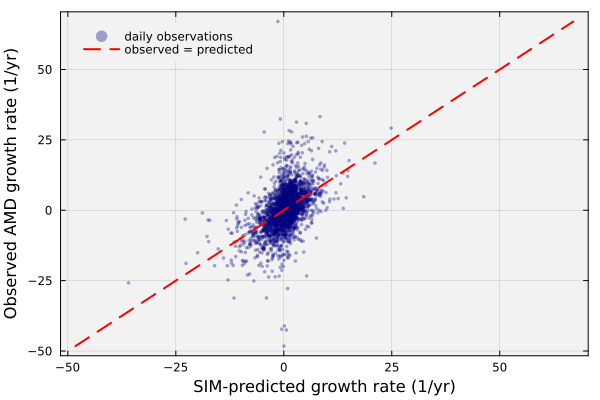

In [5]:
fitted = estimate.α .+ estimate.β .* g_market; # SIM-predicted growth rates
residuals = g_firm .- fitted; # residual growth rates ε̂ (units: 1/years)
let
    scatter(fitted, g_firm, ms = 2, msw = 0, alpha = 0.35, c = :navy, label = "daily observations")
    lims = collect(extrema(vcat(fitted, g_firm)));
    plot!(lims, lims, c = :red, ls = :dash, lw = 2, label = "observed = predicted")
    plot!(xlabel = "SIM-predicted growth rate (1/yr)", ylabel = "Observed $(my_test_ticker) growth rate (1/yr)",
        bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = :topleft)
end

___

## Task 2: Two Bootstraps Against the Classical Standard Errors
A bootstrap builds synthetic datasets from the fitted model, $\mathbf{y}^{(b)}=\hat{\mathbf{X}}\hat{\boldsymbol{\theta}}+\boldsymbol{\varepsilon}^{(b)}$, re-estimates $\boldsymbol{\theta}$ on each, and reads the spread of the re-estimates as sampling uncertainty. The two versions differ only in where $\boldsymbol{\varepsilon}^{(b)}$ comes from:

* the __empirical-residual bootstrap__ resamples the centered fitted residuals with replacement, keeping their observed one-day shape (asymmetry, heavy tails);
* the __Gaussian parametric bootstrap__ draws $\boldsymbol{\varepsilon}^{(b)}\sim\mathcal{N}(\mathbf{0},s^{2}_{g,\varepsilon}\mathbf{I})$, which is the lecture's error model and the pseudo-code in the lecture.

Both hold the market series fixed and draw innovations independently across days. [The `bootstrap_sim(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) runs either (`method = :residual` or `:parametric`), returns the samples of $(\hat{\alpha},\hat{\beta},s_{g,\varepsilon})$, empirical percentile intervals, bootstrap standard errors, and the classical covariance $s^{2}_{g,\varepsilon}(\hat{\mathbf{X}}^{\top}\hat{\mathbf{X}})^{-1}$ of the lecture (with $\delta=0$; the ridge case is treated in the optional advanced notebook). Both bootstraps assume the fitted model is the right conditional mean and that the innovations are exchangeable across days. We run both with the same seed and store them in the `residual_bootstrap::NamedTuple` and `parametric_bootstrap::NamedTuple` variables:

In [6]:
residual_bootstrap = bootstrap_sim(g_market, g_firm, my_test_ticker; n_bootstrap = number_of_bootstrap_samples, seed = seed, method = :residual);
parametric_bootstrap = bootstrap_sim(g_market, g_firm, my_test_ticker; n_bootstrap = number_of_bootstrap_samples, seed = seed, method = :parametric);
let
    rows = DataFrame(quantity = String[], residual = Float64[], parametric = Float64[], analytical = Float64[]);
    push!(rows, (quantity = "β: bootstrap SE", residual = residual_bootstrap.bootstrap_standard_errors.beta, parametric = parametric_bootstrap.bootstrap_standard_errors.beta, analytical = residual_bootstrap.theoretical_standard_errors.beta));
    t = quantile(TDist(N - 2), 0.975); # classical 95% critical value
    push!(rows, (quantity = "β: 95% CI low", residual = residual_bootstrap.confidence_intervals.beta[1], parametric = parametric_bootstrap.confidence_intervals.beta[1], analytical = estimate.β - t*residual_bootstrap.theoretical_standard_errors.beta));
    push!(rows, (quantity = "β: 95% CI high", residual = residual_bootstrap.confidence_intervals.beta[2], parametric = parametric_bootstrap.confidence_intervals.beta[2], analytical = estimate.β + t*residual_bootstrap.theoretical_standard_errors.beta));
    push!(rows, (quantity = "α: bootstrap SE (1/yr)", residual = residual_bootstrap.bootstrap_standard_errors.alpha, parametric = parametric_bootstrap.bootstrap_standard_errors.alpha, analytical = residual_bootstrap.theoretical_standard_errors.alpha));
    push!(rows, (quantity = "s_gε: 95% CI low (1/yr)", residual = residual_bootstrap.confidence_intervals.sigma_epsilon[1], parametric = parametric_bootstrap.confidence_intervals.sigma_epsilon[1], analytical = NaN));
    push!(rows, (quantity = "s_gε: 95% CI high (1/yr)", residual = residual_bootstrap.confidence_intervals.sigma_epsilon[2], parametric = parametric_bootstrap.confidence_intervals.sigma_epsilon[2], analytical = NaN));
    rows.residual = round.(rows.residual, digits=4); rows.parametric = round.(rows.parametric, digits=4); rows.analytical = round.(rows.analytical, digits=4);
    pretty_table(rows, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
end

 -------------------------- ---------- ------------ ------------
                  quantity   residual   parametric   analytical 
                    String    Float64      Float64      Float64 
 -------------------------- ---------- ------------ ------------
           β: bootstrap SE     0.0567       0.0579        0.058
             β: 95% CI low     1.6225       1.6286       1.6254
            β: 95% CI high     1.8511        1.855       1.8529
    α: bootstrap SE (1/yr)     0.1239       0.1243       0.1245
   s_gε: 95% CI low (1/yr)     6.1796        6.371          NaN
  s_gε: 95% CI high (1/yr)     6.9444       6.7146          NaN
 -------------------------- ---------- ------------ ------------


For $\hat{\alpha}$ and $\hat{\beta}$ the three columns agree closely: those estimators are linear in the innovations, so their standard errors depend only on the innovation variance, which both bootstraps match by construction (their finite-sample interval shapes can still differ, but with $N\approx2800$ that difference is negligible). The residual standard deviation is where the two bootstraps part company: its sampling distribution depends on the fourth moment of the innovations, so the heavy-tailed empirical residuals give a wider interval than Gaussian draws with the same variance. Let's see the sampled distributions [using the `histogram(...)` function](https://docs.juliaplots.org/stable/api/#Plots.histogram-Tuple):

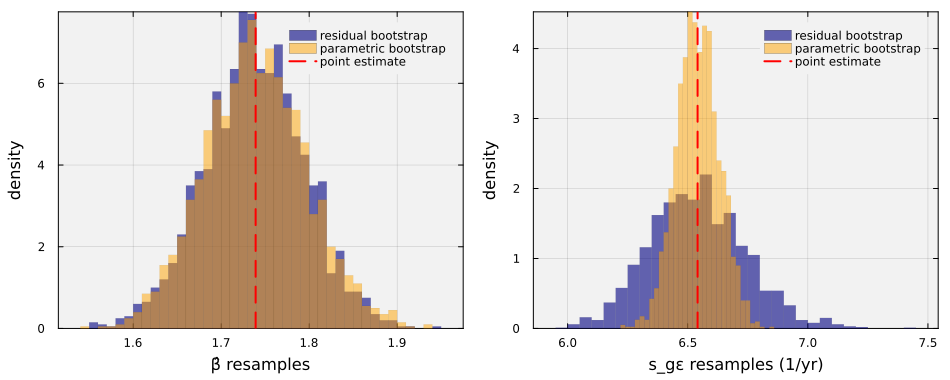

In [7]:
let
    p1 = histogram(residual_bootstrap.beta_samples, bins = 40, normalize = :pdf, c = :navy, alpha = 0.6, lw = 0, label = "residual bootstrap", xlabel = "β̂ resamples", ylabel = "density")
    histogram!(p1, parametric_bootstrap.beta_samples, bins = 40, normalize = :pdf, c = :orange, alpha = 0.5, lw = 0, label = "parametric bootstrap")
    vline!(p1, [estimate.β], c = :red, lw = 2, ls = :dash, label = "point estimate")
    p2 = histogram(residual_bootstrap.sigma_epsilon_samples, bins = 40, normalize = :pdf, c = :navy, alpha = 0.6, lw = 0, label = "residual bootstrap", xlabel = "s_gε resamples (1/yr)", ylabel = "density")
    histogram!(p2, parametric_bootstrap.sigma_epsilon_samples, bins = 40, normalize = :pdf, c = :orange, alpha = 0.5, lw = 0, label = "parametric bootstrap")
    vline!(p2, [estimate.σ_ε], c = :red, lw = 2, ls = :dash, label = "point estimate")
    plot(p1, p2, layout = (1, 2), size = (950, 380), bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, left_margin = 5Plots.mm, bottom_margin = 5Plots.mm)
end

___

## Task 3: Audit the Residual Model
Both bootstraps assumed the innovations are independent across days, and the parametric one also assumed they are Gaussian. L3a gave us the tools to check: the sample autocorrelation of the residuals and of their absolute values (dependence and volatility clustering) and a tail index. [The `stylized_facts_report(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) computes them, together with the pointwise white-noise band $\pm1.96/\sqrt{N}$ outside which a single autocorrelation is distinguishable from zero. Treat these as screening diagnostics: the band is pointwise (it ignores that we look at several lags and that the residuals come from a fit), and the Hill tail index depends on how many extreme observations it uses. We compute the report for the fitted residuals and tabulate it:

In [8]:
let
    lags = [1, 5, 10, 20, 50];
    report = stylized_facts_report(residuals; lags = lags);
    df = DataFrame(lag = lags, ACF_residual = round.(report.raw_acf, digits=3), ACF_abs_residual = round.(report.absolute_acf, digits=3), white_noise_band = round.(fill(report.white_noise_95_band, length(lags)), digits=3));
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
    println("Hill tail index of |ε̂|: $(round(report.tail_index, digits=2)) (a Gaussian would be far larger; small values mean heavy tails)")
end

 ------- -------------- ------------------ ------------------
    lag   ACF_residual   ACF_abs_residual   white_noise_band 
  Int64        Float64            Float64            Float64 
 ------- -------------- ------------------ ------------------
      1          0.169              0.157              0.037
      5         -0.039              0.047              0.037
     10           -0.0              0.032              0.037
     20           0.03              0.041              0.037
     50          0.024              0.013              0.037
 ------- -------------- ------------------ ------------------
Hill tail index of |ε̂|: 4.08 (a Gaussian would be far larger; small values mean heavy tails)


The residuals are not white noise at lag one: the first autocorrelation is far outside the band, and it is positive. Two quick checks say where it comes from. First, the raw growth rates of nearly every security in the dataset show the same positive lag-one autocorrelation. Second, the positive dependence goes away when the growth rates are built from closing prices instead of volume-weighted average prices (the `keycol` keyword of [the `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix) selects the price column): the close-to-close residual autocorrelation is small and slightly negative, the familiar microstructure sign, still just outside the pointwise band. A volume-weighted average price averages over the trading day, so part of one day's move shows up in the next day's average-to-average change; that is a property of the price series, not of this firm or of the SIM. Let's verify both:

In [9]:
let
    acf1(x) = (c = x .- mean(x); dot(c[1:end-1], c[2:end])/dot(c, c)); # sample lag-one autocorrelation
    others = findall(!=(market_ticker), list_of_tickers);
    raw_lag1 = [acf1(G[:, i]) for i ∈ others]; # raw growth rates, every security except SPY
    println("Raw growth rates (VWAP): fraction of securities with lag-one autocorrelation above the white-noise band = $(round(mean(raw_lag1 .> 1.96/sqrt(N)), digits=3)); median = $(round(median(raw_lag1), digits=3))")
    for ticker ∈ list_of_tickers # the closing prices must be finite and positive too
        @assert all(isfinite, dataset[ticker].close) && all(>(0), dataset[ticker].close)
    end
    G_close = log_growth_matrix(dataset, list_of_tickers, Δt = Δt, keycol = :close); # same firms, closing prices
    g_market_close = G_close[:, findfirst(==(market_ticker), list_of_tickers)]; g_firm_close = G_close[:, findfirst(==(my_test_ticker), list_of_tickers)];
    e_close = estimate_sim(g_market_close, g_firm_close, my_test_ticker; δ = 0.0);
    residuals_close = g_firm_close .- (e_close.α .+ e_close.β .* g_market_close);
    println("$(my_test_ticker) SIM residual lag-one autocorrelation: VWAP prices = $(round(acf1(residuals), digits=3)), closing prices = $(round(acf1(residuals_close), digits=3)) (β̂ = $(round(estimate.β, digits=3)) vs $(round(e_close.β, digits=3)))")
end

Raw growth rates (VWAP): fraction of securities with lag-one autocorrelation above the white-noise band = 0.981; median = 0.104
AMD SIM residual lag-one autocorrelation: VWAP prices = 0.169, closing prices = -0.045 (β̂ = 1.739 vs 1.636)


So the positive lag-one dependence is real, shared, and tied to the price series, and it violates the independence that the classical formulas and both bootstraps assume. Positive dependence in the products $\hat{\mathbf{x}}_{t}r_{t}$ makes the classical standard errors too small. A __heteroskedasticity- and autocorrelation-consistent__ (Newey-West) covariance replaces $s^{2}_{g,\varepsilon}(\hat{\mathbf{X}}^{\top}\hat{\mathbf{X}})^{-1}$ by $(\hat{\mathbf{X}}^{\top}\hat{\mathbf{X}})^{-1}\hat{\mathbf{S}}(\hat{\mathbf{X}}^{\top}\hat{\mathbf{X}})^{-1}$, where $\hat{\mathbf{S}}$ sums the outer products $\hat{\mathbf{x}}_{t}\hat{\mathbf{x}}_{t-\ell}^{\top}\,r_{t}r_{t-\ell}$ (and their transposes) over lags $\ell=0,\dots,L$ with Bartlett weights $1-\ell/(L+1)$, $\hat{\mathbf{x}}_{t}$ being row $t$ of the design matrix. Let's compute it for a few lag lengths and compare with the classical standard errors (the case $L=0$ corrects for heteroskedasticity only):

In [10]:
let
    X̂ = [ones(N) g_market]; XtX_inv = inv(transpose(X̂)*X̂); r = residuals;
    classical = sqrt.(estimate.σ_ε^2 .* diag(XtX_inv));
    function newey_west(L)
        S = zeros(2, 2);
        for t ∈ 1:N; S += (X̂[t, :]*transpose(X̂[t, :]))*r[t]^2; end
        for ℓ ∈ 1:L
            w = 1 - ℓ/(L + 1); Sℓ = zeros(2, 2);
            for t ∈ (ℓ+1):N; Sℓ += (X̂[t, :]*transpose(X̂[t-ℓ, :]))*r[t]*r[t-ℓ]; end
            S += w*(Sℓ + transpose(Sℓ));
        end
        sqrt.(diag(XtX_inv*S*XtX_inv))
    end
    df = DataFrame(method = String[], SE_α = Float64[], SE_β = Float64[], ratio_β = Float64[]);
    push!(df, (method = "classical", SE_α = round(classical[1], digits=4), SE_β = round(classical[2], digits=4), ratio_β = 1.0));
    for L ∈ [0, 5, 10, 20]
        se = newey_west(L); push!(df, (method = "Newey-West, L = $(L)", SE_α = round(se[1], digits=4), SE_β = round(se[2], digits=4), ratio_β = round(se[2]/classical[2], digits=3)));
    end
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
end

 -------------------- --------- --------- ---------
              method      SE_α      SE_β   ratio_β 
              String   Float64   Float64   Float64 
 -------------------- --------- --------- ---------
           classical    0.1245     0.058       1.0
   Newey-West, L = 0     0.125    0.0665     1.146
   Newey-West, L = 5    0.1409    0.0828     1.428
  Newey-West, L = 10    0.1395    0.0968     1.668
  Newey-West, L = 20    0.1373    0.1142      1.97
 -------------------- --------- --------- ---------


The autocorrelation-consistent standard error of $\hat{\beta}$ is materially larger than the classical one, by roughly forty percent at five lags and approaching double at twenty; the intercept's grows less. Three consequences follow. The classical and bootstrap intervals for beta are optimistic for these data, and a robust standard error or a block bootstrap (which resamples stretches of consecutive days) is the credible interval; the residual bootstrap still keeps the observed tail shape that matters for the residual scale; and for anything that accumulates over many days (a portfolio's wealth path, the multi-day risk of L6b and L7b) the persistence in the residuals must be modeled rather than resampled away. For a portfolio of many securities there is a further gap: bootstrapping each regression on its own discards the residual correlation across securities that the estimation example measured. The absolute residuals, finally, show the same lag-one dependence and only marginal persistence beyond it, so the volatility clustering of L3a is weaker in the SIM residual than in the raw growth rates, and the tail index says the residuals are heavy-tailed.
___

## Summary
In this example, we fit a single index model with the course package, bootstrapped its parameters with empirical residuals and with Gaussian innovations, compared both with the classical standard errors, audited the residuals for the dependence and heavy tails that the bootstraps ignore, and measured what an autocorrelation-consistent standard error does about the dependence.

> __Key Takeaways:__
>
> * **The intercept and beta inherit only the innovation variance:** The bootstrap standard errors of the intercept and beta match the classical values under both innovation models, because those estimators are linear in the innovations, so with independent draws the innovation shape barely matters for them.
> * **The residual scale does depend on the innovation shape:** The sampling distribution of the residual standard deviation depends on the fourth moment of the innovations, so heavy-tailed empirical residuals give a wider interval than Gaussian draws with the same variance.
> * **Independent draws are an assumption to audit:** The fitted residuals carry a positive lag-one autocorrelation (a property of growth rates built from volume-weighted average prices) and heavy tails, so the classical and bootstrap standard errors of beta are optimistic, an autocorrelation-consistent standard error is materially larger, independent-draws methods understate multi-day risk, and, run security by security, discard cross-security residual correlation.

L6b takes the point estimates into a portfolio covariance; the uncertainty measured here is what the L6b forward-validation example propagates into weights.
___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___